# Art Style Classification on WikiArt

`Runtime → Change runtime type → T4 GPU`

Mount Google Drive


## 0. Setup

In [1]:
# Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import os

DRIVE_ROOT   = '/content/drive/MyDrive/wikiart'
CKPT_DIR     = os.path.join(DRIVE_ROOT, 'checkpoints')
OUTPUT_DIR   = os.path.join(DRIVE_ROOT, 'outputs')
DATA_RAW     = os.path.join(DRIVE_ROOT, 'data/raw')
DATA_FULL    = os.path.join(DRIVE_ROOT, 'data/processed')

for d in [CKPT_DIR, OUTPUT_DIR, DATA_RAW, DATA_FULL]:
    os.makedirs(d, exist_ok=True)

print('Drive folders ready.')

Drive folders ready.


In [5]:
# Clone GitHub repo
REPO_URL = 'https://github.com/yuyaoxu11-bit/Art-Style-Classification-WikiArt'

if not os.path.exists('/content/wikiart'):
    !git clone {REPO_URL} /content/wikiart
else:
    !cd /content/wikiart && git pull

%cd /content/wikiart

Cloning into '/content/wikiart'...
remote: Enumerating objects: 40, done.
remote: Counting objects: 100% (40/40), done.
remote: Compressing objects: 100% (33/33), done.
remote: Total 40 (delta 5), reused 40 (delta 5), pack-reused 0 (from 0)
Receiving objects: 100% (40/40), 24.87 KiB | 848.00 KiB/s, done.
Resolving deltas: 100% (5/5), done.
/content/wikiart


In [6]:
!pip install -r requirements.txt -q

In [7]:
# Verify GPU is available
import torch
print(f'CUDA available: {torch.cuda.is_available()}')
print(f'Device: {torch.cuda.get_device_name(0) if torch.cuda.is_available() else "CPU"}')

CUDA available: True
Device: Tesla T4


## 1. Prepare Dataset
Downloads WikiArt and creates balanced train/val/test splits (1500 images/class).  
**Skip this cell if `data/processed` already exists in Drive.**

In [9]:
import shutil
shutil.rmtree('/content/drive/MyDrive/wikiart/data/raw')
shutil.rmtree('/content/drive/MyDrive/wikiart/data/processed', ignore_errors=True)

In [11]:
# Check if dataset already prepared
if os.path.exists(os.path.join(DATA_FULL, 'train')):
    print('Dataset already prepared, skipping download.')
else:
    !python prepare_dataset.py \
        --source_dir {DATA_RAW} \
        --output_dir {DATA_FULL}

Mode: FULL — 1500 images/class
Loading WikiArt dataset from HuggingFace...
[Realism] Saved 3000 images
[Romanticism] Saved 3000 images
[Impressionism] Saved 3000 images
[Baroque] Saved 3000 images
[Abstract_Expressionism] Saved 2074 images
[Cubism] Saved 1747 images

Raw images written to: /content/drive/MyDrive/wikiart/data/raw
[Impressionism] train=1050  val=225  test=225
[Baroque] train=1050  val=225  test=225
[Cubism] train=1050  val=225  test=225
[Romanticism] train=1050  val=225  test=225
[Realism] train=1050  val=225  test=225
[Abstract_Expressionism] train=1050  val=225  test=225

Dataset written to: /content/drive/MyDrive/wikiart/data/processed


## 2. Train CNN Baseline

In [12]:
!python train_baseline.py \
    --data_dir   {DATA_FULL} \
    --epochs     20 \
    --batch_size 32 \
    --lr         1e-3

Using device: cuda
Classes (6): ['Abstract_Expressionism', 'Baroque', 'Cubism', 'Impressionism', 'Realism', 'Romanticism']
Train: 6300  Val: 1350  Test: 1350
Total parameters:     51,477,062
Trainable parameters: 51,477,062
Epoch   1/20 | Train Loss: 1.7351  Acc: 0.3071 | Val Loss: 1.5032  Acc: 0.3741
  -> Saved best model (val_acc=0.3741)
Epoch   2/20 | Train Loss: 1.4990  Acc: 0.3937 | Val Loss: 1.4201  Acc: 0.4185
  -> Saved best model (val_acc=0.4185)
Epoch   3/20 | Train Loss: 1.4232  Acc: 0.4200 | Val Loss: 1.3751  Acc: 0.4444
  -> Saved best model (val_acc=0.4444)
Epoch   4/20 | Train Loss: 1.3361  Acc: 0.4737 | Val Loss: 1.3340  Acc: 0.4541
  -> Saved best model (val_acc=0.4541)
Epoch   5/20 | Train Loss: 1.2634  Acc: 0.5054 | Val Loss: 1.3011  Acc: 0.4904
  -> Saved best model (val_acc=0.4904)
Epoch   6/20 | Train Loss: 1.1634  Acc: 0.5460 | Val Loss: 1.3227  Acc: 0.4622
Epoch   7/20 | Train Loss: 1.0727  Acc: 0.5906 | Val Loss: 1.2929  Acc: 0.4807
Epoch   8/20 | Train Loss: 0

In [13]:
# Copy checkpoint to Drive
!cp checkpoints/cnn_baseline.pth {CKPT_DIR}/
!cp outputs/cnn_baseline_curves.png {OUTPUT_DIR}/
print('Saved to Drive.')

Saved to Drive.


## 3. Transfer Learning — ResNet18 (frozen backbone)

In [14]:
!python train_transfer.py \
    --data_dir   {DATA_FULL} \
    --strategy   frozen \
    --epochs     20 \
    --batch_size 32

Strategy: frozen | Device: cuda
Classes (6): ['Abstract_Expressionism', 'Baroque', 'Cubism', 'Impressionism', 'Realism', 'Romanticism']
Train: 6300  Val: 1350  Test: 1350
Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth
100% 44.7M/44.7M [00:00<00:00, 173MB/s]
Total parameters:     11,179,590
Trainable parameters: 3,078
Epoch   1/20 | Train Loss: 1.2549  Acc: 0.4978 | Val Loss: 1.0476  Acc: 0.5696
  -> Saved best model (val_acc=0.5696)
Epoch   2/20 | Train Loss: 0.9971  Acc: 0.6071 | Val Loss: 0.9249  Acc: 0.6281
  -> Saved best model (val_acc=0.6281)
Epoch   3/20 | Train Loss: 0.9392  Acc: 0.6317 | Val Loss: 0.8881  Acc: 0.6548
  -> Saved best model (val_acc=0.6548)
Epoch   4/20 | Train Loss: 0.9006  Acc: 0.6410 | Val Loss: 0.8836  Acc: 0.6467
Epoch   5/20 | Train Loss: 0.8729  Acc: 0.6567 | Val Loss: 0.8511  Acc: 0.6593
  -> Saved best model (val_acc=0.6593)
Epoch   6/20 | Train Loss: 0.8603  Acc: 0.65

In [15]:
!cp checkpoints/resnet18_frozen.pth {CKPT_DIR}/
!cp outputs/resnet18_frozen_curves.png {OUTPUT_DIR}/
print('Saved to Drive.')

Saved to Drive.


## 4. Transfer Learning — ResNet18 (full fine-tuning)

In [16]:
!python train_transfer.py \
    --data_dir   {DATA_FULL} \
    --strategy   full \
    --epochs     20 \
    --batch_size 32

Strategy: full | Device: cuda
Classes (6): ['Abstract_Expressionism', 'Baroque', 'Cubism', 'Impressionism', 'Realism', 'Romanticism']
Train: 6300  Val: 1350  Test: 1350
Total parameters:     11,179,590
Trainable parameters: 11,179,590
Epoch   1/20 | Train Loss: 0.9304  Acc: 0.6281 | Val Loss: 0.7778  Acc: 0.7030
  -> Saved best model (val_acc=0.7030)
Epoch   2/20 | Train Loss: 0.5732  Acc: 0.7830 | Val Loss: 0.7855  Acc: 0.7074
  -> Saved best model (val_acc=0.7074)
Epoch   3/20 | Train Loss: 0.3626  Acc: 0.8687 | Val Loss: 0.7469  Acc: 0.7267
  -> Saved best model (val_acc=0.7267)
Epoch   4/20 | Train Loss: 0.2233  Acc: 0.9287 | Val Loss: 0.7468  Acc: 0.7319
  -> Saved best model (val_acc=0.7319)
Epoch   5/20 | Train Loss: 0.1530  Acc: 0.9529 | Val Loss: 0.7885  Acc: 0.7222
Epoch   6/20 | Train Loss: 0.1222  Acc: 0.9638 | Val Loss: 0.8487  Acc: 0.7363
  -> Saved best model (val_acc=0.7363)
Epoch   7/20 | Train Loss: 0.0968  Acc: 0.9700 | Val Loss: 0.9014  Acc: 0.7385
  -> Saved best m

In [17]:
!cp checkpoints/resnet18_full.pth {CKPT_DIR}/
!cp outputs/resnet18_full_curves.png {OUTPUT_DIR}/
print('Saved to Drive.')

Saved to Drive.


## 5. Evaluate All Models

In [18]:
!python evaluate.py --data_dir {DATA_FULL}

Using device: cuda

Evaluating: CNN Baseline
Classes (6): ['Abstract_Expressionism', 'Baroque', 'Cubism', 'Impressionism', 'Realism', 'Romanticism']
Train: 6300  Val: 1350  Test: 1350
                        precision    recall  f1-score   support

Abstract_Expressionism       0.54      0.52      0.53       225
               Baroque       0.52      0.55      0.53       225
                Cubism       0.59      0.66      0.62       225
         Impressionism       0.45      0.55      0.49       225
               Realism       0.35      0.28      0.32       225
           Romanticism       0.41      0.34      0.37       225

              accuracy                           0.48      1350
             macro avg       0.48      0.48      0.48      1350
          weighted avg       0.48      0.48      0.48      1350

Saved: outputs/confusion_CNN_Baseline.png

Evaluating: ResNet18 (frozen)
Classes (6): ['Abstract_Expressionism', 'Baroque', 'Cubism', 'Impressionism', 'Realism', 'Romanticis

In [19]:
# Copy confusion matrices to Drive
!cp outputs/confusion_*.png {OUTPUT_DIR}/
print('Evaluation outputs saved to Drive.')

Evaluation outputs saved to Drive.


## 6. Visualize Results

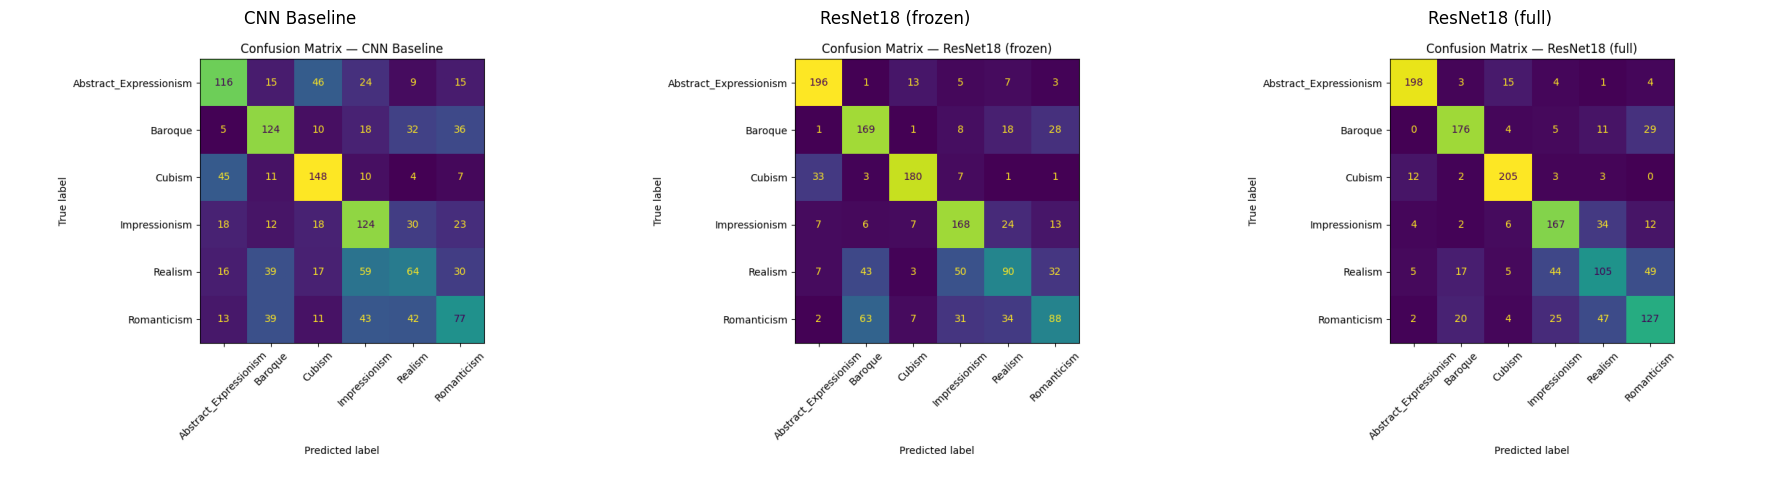

In [20]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
titles = ['CNN Baseline', 'ResNet18 (frozen)', 'ResNet18 (full)']
files  = ['confusion_CNN_Baseline.png',
          'confusion_ResNet18_frozen.png',
          'confusion_ResNet18_full.png']

for ax, title, fname in zip(axes, titles, files):
    path = os.path.join(OUTPUT_DIR, fname)
    if os.path.exists(path):
        ax.imshow(mpimg.imread(path))
        ax.set_title(title)
        ax.axis('off')

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'all_confusion_matrices.png'), dpi=150)
plt.show()

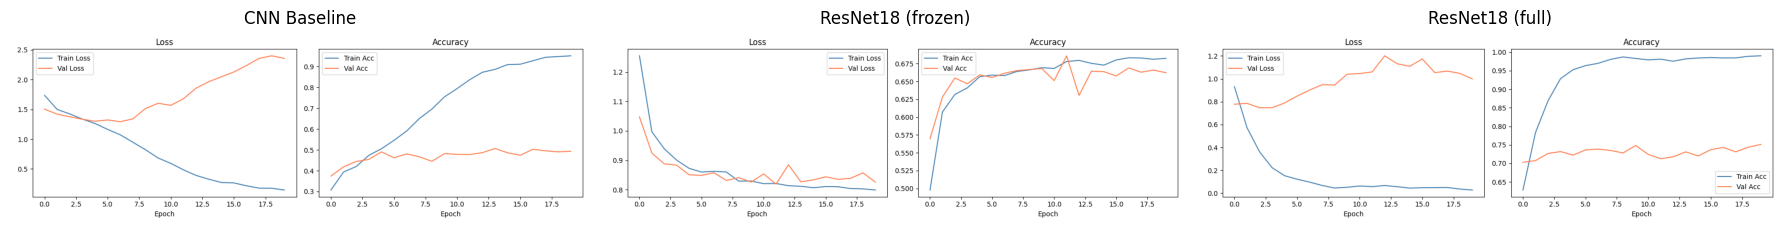

In [21]:
# Training curves side by side
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
curve_files = ['cnn_baseline_curves.png',
               'resnet18_frozen_curves.png',
               'resnet18_full_curves.png']

for ax, title, fname in zip(axes, titles, curve_files):
    path = os.path.join(OUTPUT_DIR, fname)
    if os.path.exists(path):
        ax.imshow(mpimg.imread(path))
        ax.set_title(title)
        ax.axis('off')

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'all_training_curves.png'), dpi=150)
plt.show()

## 7. Push Best Model to Hugging Face Hub

In [23]:
!pip install huggingface_hub -q

from huggingface_hub import HfApi

HF_TOKEN   = 'hf_***'
HF_REPO_ID = 'yyx11/wikiart-style-classifier'

api = HfApi()

api.create_repo(repo_id=HF_REPO_ID, token=HF_TOKEN, exist_ok=True)

# Upload best checkpoint
api.upload_file(
    path_or_fileobj=os.path.join(CKPT_DIR, 'resnet18_full.pth'),
    path_in_repo='resnet18_full.pth',
    repo_id=HF_REPO_ID,
    token=HF_TOKEN,
)
print(f'Model uploaded to https://huggingface.co/{HF_REPO_ID}')

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


Processing Files (0 / 0)      : |          |  0.00B /  0.00B            

New Data Upload               : |          |  0.00B /  0.00B            

  ...kpoints/resnet18_full.pth:   1%|1         |  565kB / 44.8MB            

Model uploaded to https://huggingface.co/yyx11/wikiart-style-classifier


In [24]:
import nbformat

with open('wikiart_colab.ipynb', 'r') as f:
    nb = nbformat.read(f, as_version=4)

if 'widgets' in nb.metadata:
    del nb.metadata['widgets']

with open('wikiart_colab.ipynb', 'w') as f:
    nbformat.write(nb, f)

print('Done')

Done
